<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_12%EF%BC%9A%E7%9B%A3%E7%9D%A3%E5%BC%8F%E5%AD%B8%E7%BF%92%E2%80%94%E2%80%94%E5%9B%9E%E6%AD%B8%E6%A8%A1%E5%9E%8B_%26_%E5%88%86%E9%A1%9E%E6%A8%A1%E5%9E%8B%E5%9C%A8%E8%82%A1%E5%83%B9%E4%B8%8A%E9%A0%90%E6%B8%AC%E4%B8%8A%E7%9A%84%E9%81%8B%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-09-27 15:43:28--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.251.111.113, 142.251.111.101, 142.251.111.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.111.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-09-27 15:43:28--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.163.132, 2607:f8b0:4004:c1b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.163.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M   129MB/s    in 0.2s    

2024-09-27 

在本節中，我們將深入學習監督式機器學習的兩大主要分支：回歸模型和分類模型。首先，我們將應用線性回歸和決策樹等模型來預測股價，並使用均方誤差（MSE）等指標評估模型性能。接著，我們將使用邏輯回歸、支持向量機（SVM）等模型預測價格走勢方向，並通過準確率、混淆矩陣等指標評估分類模型的效果。

### **一、監督式學習概述**

監督式學習是一種機器學習方法，利用帶有標籤的數據進行模型訓練，以預測未知數據的結果。根據預測目標的不同，監督式學習可分為：

- **回歸問題**：預測連續的數值，例如股價、收益率等。
- **分類問題**：預測離散的類別，例如價格上漲或下跌。
![https://ithelp.ithome.com.tw/upload/images/20240927/20120549kzEQspih4P.jpg](https://ithelp.ithome.com.tw/upload/images/20240927/20120549kzEQspih4P.jpg)
---

### **二、回歸模型**

#### **1. 線性回歸**

##### **(1) 概念**

線性回歸試圖找到自變量 $ X $ 與因變量 $ Y $ 之間的線性關係，模型形式為：

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon
$$

其中，$ \beta $ 是模型參數，$ \epsilon $ 是誤差項。

##### **(2) 應用於股價預測**

- **目標**：預測未來的股票價格或收益率。
- **特徵選擇**：技術指標、歷史價格、成交量等。

##### **(3) Python實現**

[*********************100%***********************]  1 of 1 completed



均方誤差（MSE）：27.42


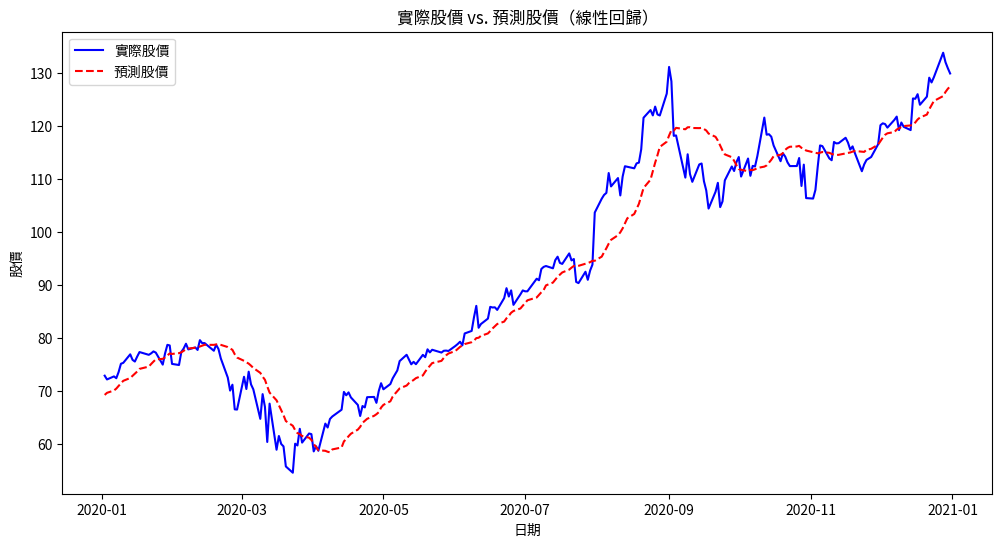

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 獲取數據
data = yf.download('AAPL', start='2015-01-01', end='2021-01-01')

# 特徵工程
data['Returns'] = data['Adj Close'].pct_change()
data['SMA'] = data['Adj Close'].rolling(window=20).mean()
data['Volatility'] = data['Returns'].rolling(window=20).std()
data.dropna(inplace=True)

# 構建特徵和標籤
X = data[['SMA', 'Volatility']]
y = data['Adj Close']

# 分割訓練集和測試集
X_train = X[X.index < '2020-01-01']
X_test = X[X.index >= '2020-01-01']
y_train = y[y.index < '2020-01-01']
y_test = y[y.index >= '2020-01-01']

# 標準化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 建立模型
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 預測
y_pred = model.predict(X_test_scaled)

# 評估模型
mse = mean_squared_error(y_test, y_pred)
print()
print(f'均方誤差（MSE）：{mse:.2f}')

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='實際股價', color='blue')
plt.plot(y_test.index, y_pred, label='預測股價', color='red', linestyle='--')
plt.title('實際股價 vs. 預測股價（線性回歸）')
plt.xlabel('日期')
plt.ylabel('股價')
plt.legend()
plt.savefig("regression_predict.png")

##### **(4) 模型評估**

- **均方誤差（MSE）**：

  $$
  \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $$

  反映了預測值與實際值之間的平均平方差，值越小，模型性能越好。

- **決定係數（$ R^2 $）**：

  $$
  R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
  $$

  反映了模型解釋變異的能力，值越接近1，模型越好。

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f'決定係數（R^2）：{r2:.2f}')

決定係數（R^2）：0.94


#### **2. 決策樹回歸**

##### **(1) 概念**

決策樹回歸使用樹狀結構將數據分割為多個區間，在每個區間內使用平均值進行預測。

##### **(2) Python實現**


均方誤差（MSE）：983.87


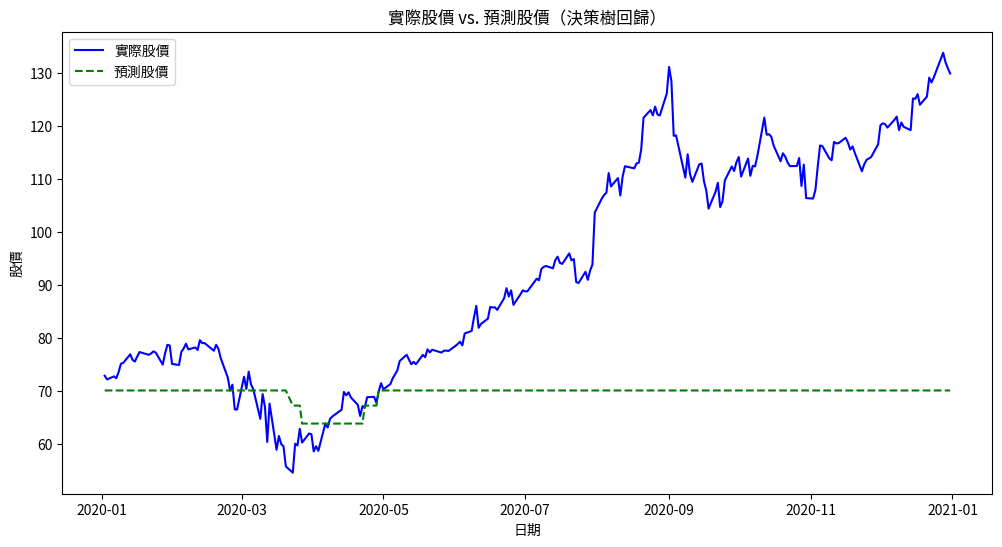

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# 建立模型
model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train_scaled, y_train)

# 預測
y_pred_tree = model.predict(X_test_scaled)

# 評估模型
mse = mean_squared_error(y_test, y_pred)
print()
print(f'均方誤差（MSE）：{mse:.2f}')

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='實際股價', color='blue')
plt.plot(y_test.index, y_pred_tree, label='預測股價', color='green', linestyle='--')
plt.title('實際股價 vs. 預測股價（決策樹回歸）')
plt.xlabel('日期')
plt.ylabel('股價')
plt.legend()
plt.show()

##### **(3) 模型優化**

- **調整樹的深度（`max_depth`）**：防止過擬合。
- **剪枝**：減少樹的複雜度。

---

### **三、分類模型**

#### **1. 邏輯回歸**

##### **(1) 概念**

邏輯回歸用於處理二分類問題，模型形式為：

$$
P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_n X_n)}}
$$

##### **(2) 應用於價格走勢預測**

- **目標**：預測明天的價格是上漲（1）還是下跌（0）。
- **特徵選擇**：技術指標、歷史收益率等。

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 構建標籤
data['Target'] = np.where(data['Returns'] > 0, 1, 0)

# 更新特徵和標籤
y = data['Target']
X_train = X_train_scaled
X_test = X_test_scaled
y_train = y[y.index < '2020-01-01']
y_test = y[y.index >= '2020-01-01']

# 建立模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 預測
y_pred = model.predict(X_test)

# 評估模型
accuracy = accuracy_score(y_test, y_pred)
print(f'準確率：{accuracy:.2%}')

# 混淆矩陣
cm = confusion_matrix(y_test, y_pred)
print('混淆矩陣：\n', cm)

# 分類報告
report = classification_report(y_test, y_pred)
print('分類報告：\n', report)

準確率：54.15%
混淆矩陣：
 [[  0 116]
 [  0 137]]
分類報告：
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       116
           1       0.54      1.00      0.70       137

    accuracy                           0.54       253
   macro avg       0.27      0.50      0.35       253
weighted avg       0.29      0.54      0.38       253



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### **2. 支持向量機（SVM）**

##### **(1) 概念**

SVM試圖找到一個最佳的超平面，將數據劃分為不同的類別，這裡我們不展開數學，並最大化分類間隔，有興趣的朋友可以去[這裡](https://www.youtube.com/watch?v=A-GxGCCAIrg)了解細節。

##### **(2) Python實現**

In [ ]:
from sklearn.svm import SVC

# 建立模型
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# 預測
y_pred = model.predict(X_test)

# 評估模型
accuracy = accuracy_score(y_test, y_pred)
print(f'準確率：{accuracy:.2%}')

準確率：54.15%


##### **(3) 模型優化**
​
- **調整超參數**：如`C`、`gamma`、`kernel`等。
- **使用交叉驗證**：選擇最佳參數組合。
​
#### **3. 評估分類模型**
​
##### **(1) 準確率（Accuracy）**
​
$$
\text{Accuracy} = \frac{\text{正確預測數}}{\text{總預測數}}
$$
​
##### **(2) 混淆矩陣**
​
|            | 實際正類 | 實際負類 |
|------------|----------|----------|
| **預測正類** | 真正類 (TP) | 假正類 (FP) |
| **預測負類** | 假負類 (FN) | 真負類 (TN) |
​
##### **(3) 評估指標**
​
- **精確率（Precision）**：
​
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$
​
- **召回率（Recall）**：
​
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$
​
- **F1-score**：
​
  $$
  \text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $$
​
---
​
### **四、模型比較與選擇**
​
#### **1. 回歸模型的比較**
​
- **MSE、$ R^2 $**等指標用於比較不同回歸模型的性能。
- **模型簡單性**：線性回歸易於解釋，決策樹可處理非線性關係。
​
#### **2. 分類模型的比較**
​
- **準確率、精確率、召回率**等指標綜合評估模型。
- **選擇適合的模型**：根據數據特性和業務需求選擇。
​
#### **3. 過擬合與欠擬合**
​
- **過擬合**：模型在訓練集上表現良好，但在測試集上表現較差。
- **欠擬合**：模型在訓練集和測試集上都表現不佳。
​
**解決方法**：
​
- **過擬合**：使用正則化、剪枝、減少模型複雜度、增加數據量。
- **欠擬合**：增加模型複雜度、添加更多特徵。
​
---
​
### **五、實際案例：模型應用與評估**
​
#### **1. 整合所有步驟**
​
將前面的代碼整合，對不同的模型進行訓練和評估。
​
#### **2. 可視化結果**

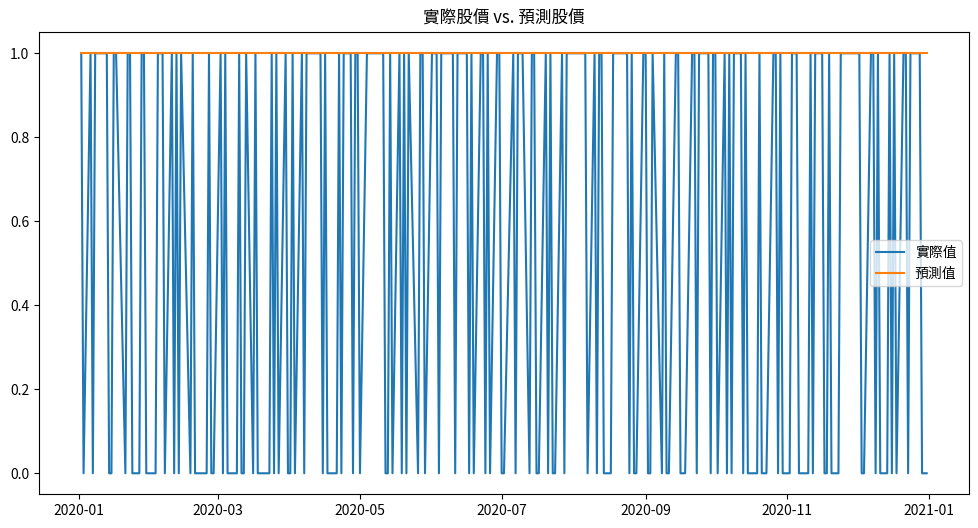

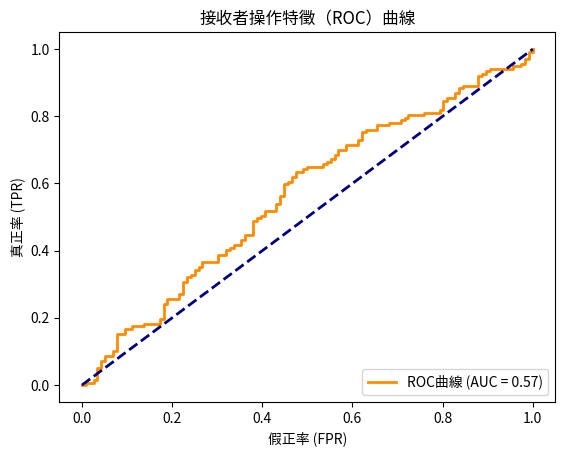

In [ ]:
import matplotlib.pyplot as plt

# 回歸結果可視化
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='實際值')
plt.plot(y_test.index, y_pred, label='預測值')
plt.title('實際股價 vs. 預測股價')
plt.legend()
plt.show()

# 分類結果可視化
from sklearn.metrics import roc_curve, auc

# 計算ROC曲線
y_score = model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# 繪製ROC曲線
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲線 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('假正率 (FPR)')
plt.ylabel('真正率 (TPR)')
plt.title('接收者操作特徵（ROC）曲線')
plt.legend(loc='lower right')
plt.show()

### **六、總結**

在本節中，我們：

- **學習了回歸模型的應用**，如線性回歸和決策樹回歸，用於預測連續的股價。
- **學習了分類模型的應用**，如邏輯回歸和支持向量機，用於預測股價的上漲或下跌。
- **掌握了模型評估方法**，包括均方誤差、準確率、混淆矩陣等。
- **理解了模型選擇和優化的原則**，如防止過擬合、調整超參數等。

*在接下來的學習中，我們將進一步探討模型優化和交叉驗證等技術，以提高模型的泛化能力和性能。*

---

**作業：**

1. **嘗試其他模型**：如隨機森林回歸和分類，比較其性能。
2. **參數調優**：使用網格搜索（Grid Search）調整模型的超參數，尋找最佳參數組合。
3. **擴展特徵集**：添加更多的技術指標或基本面數據，觀察對模型性能的影響。

*透過實踐，您將更深入地理解監督式學習模型在金融領域的應用，並掌握模型構建和評估的技巧。*

---

**提示：**

- **交叉驗證**：使用`cross_val_score`等方法對模型進行交叉驗證，評估模型的穩定性。

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print('交叉驗證MSE：', -scores)

交叉驗證MSE： [0.57258065 0.5483871  0.56048387 0.51821862 0.50202429]


- **網格搜索**：使用`GridSearchCV`自動調整模型的超參數。


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print('最佳參數：', grid.best_params_)

最佳參數： {'C': 0.1, 'gamma': 'scale'}


- **特徵重要性**：對於決策樹和隨機森林等模型，可以查看特徵的重要性。

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=X.columns)
print('特徵重要性：\n', feature_importance)

特徵重要性：
 SMA           0.500333
Volatility    0.499667
dtype: float64


**注意：**

- **資料洩漏**：在模型訓練和測試中，務必防止未來數據洩漏到訓練過程中。
- **過擬合風險**：在調整模型時，注意避免過度擬合訓練數據，導致測試集性能下降。
- **評估多個指標**：不要僅依賴單一評估指標，綜合考慮模型的各方面性能。